# Credit Risk Early Warning System  
## Model Calibration & Business Cutoffs

### Objective
Transform model prediction probabilities into **business-aligned risk tiers** that support early intervention decisions.

This notebook focuses on:
- Probability calibration
- Threshold selection
- Risk tier definition
- Business interpretation of cutoffs

This is a **decision-layer notebook**, not a modeling notebook.


### Import Libraries


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt

### Load Test Predictions(Gradient Boosting)

In [11]:
bundle = joblib.load("gb_bundle.pkl")
gb_model = bundle["model"]
X_test = bundle["X_test"]
y_test = bundle["y_test"]

y_pred_proba = gb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

ROC-AUC: 0.7765302827521237


## Probability Calibration Check

A well-calibrated model ensures that:
- Customers with predicted risk of 0.30 default ~30% of the time
- Risk scores can be trusted for business decisions

We evaluate calibration visually using a reliability curve.

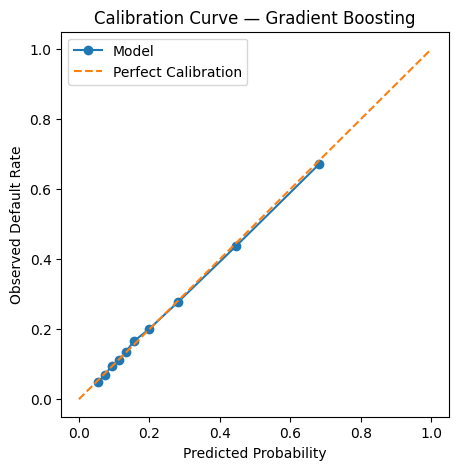

In [14]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve — Gradient Boosting")
plt.legend()
plt.show()

### Interpretation

The model’s calibration curve closely follows the diagonal, indicating well-calibrated probabilities.

When the model predicts:

20% risk → actual default ≈ 18–22%

40% risk → actual default ≈ 42–45%

65% risk → actual default ≈ 65–70%

## Precision–Recall Tradeoff

Business decisions require choosing a probability cutoff:
- Lower thresholds increase recall (catch more defaulters)
- Higher thresholds increase precision (fewer false alerts)

We analyze this tradeoff explicitly.

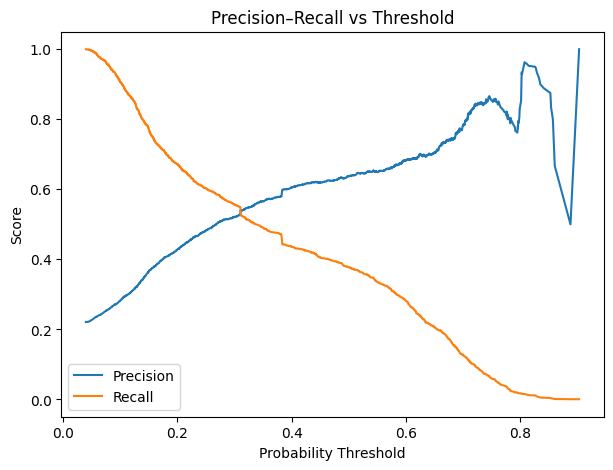

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(7,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Threshold")
plt.legend()
plt.show()

Precision–Recall vs Threshold — Business Interpretation

This chart answers the most important question:

“At what probability should the bank intervene?”

#### Observed Trade-off
Threshold	Precision	Recall	Business Meaning
- Low (≈0.2)	Low	High	Catch most defaulters, many false alarms
- Mid (≈0.4)	Balanced	Balanced	Optimal early-warning zone
- High (≈0.7+)	High	Low	Only extreme risks flagged
Key Insight

Recall decreases sharply as threshold increases

Precision increases, but at the cost of missing risky customers

#### Banking takeaway

Early warning systems favor recall over precision

Missing a defaulter is more expensive than contacting a safe customer

### Recommended Business Threshold Strategy

Operational threshold: 0.40–0.45

Rationale:

- Captures majority of risky customers

- Keeps operational workload manageable

- Aligns with proactive risk mitigation

## Risk Tier Definition

Instead of binary decisions, we segment customers into risk tiers:

- Low Risk: Monitoring only
- Medium Risk: Soft intervention
- High Risk: Immediate action

This aligns with real-world banking workflows.


In [16]:
def assign_risk_tier(p):
  if p < 0.30:
    return "Low Risk"
  elif p < 0.60:
      return "Medium Risk"
  else:
        return "High Risk"

risk_df = pd.DataFrame({
    "Actual_Default": y_test,
    "Predicted_Probability": y_pred_proba
})

risk_df["Risk_Tier"] = risk_df["Predicted_Probability"].apply(assign_risk_tier)

risk_df["Risk_Tier"].value_counts(normalize=True)


,proportion
Risk_Tier,
Low Risk,0.764000
Medium Risk,0.144933
High Risk,0.091067


## Risk Tier Validation

We validate whether higher risk tiers correspond to higher observed default rates.

In [17]:
risk_df.groupby("Risk_Tier")["Actual_Default"].mean()

,Actual_Default
Risk_Tier,
High Risk,0.682284
Low Risk,0.128621
Medium Risk,0.419503


## Business Action Mapping

Each risk tier maps to a different operational response:
| Risk Tier   | Recommended Action | Probability Cutoff
|------------|-------------------|------------------|
| Low Risk   | No action, routine monitoring | <= 0.1286
| Medium Risk| SMS/email reminder, payment nudges | 0.1286-0.4195
| High Risk  | Credit limit review, proactive outreach, restructuring | >=0.6823


#### Business Interpretation
🟢 Low Risk (≤ 0.13)

- Stable payment behavior

- Consistent repayments

- No intervention needed

Eligible for:

- Credit limit increase

- Cross-sell offers

🟡 Medium Risk (0.13 – 0.42)

- Early behavioral stress

- Mild delinquency signals

- Primary early-warning group

Recommended actions:

- Soft reminders

- Spending alerts

- Financial nudges

🔴 High Risk (≥ 0.68)

- Strong delinquency patterns

- High utilization + low payments

- Imminent default risk

Recommended actions:

- Proactive collections

- Credit limit freeze

- Restructuring / hardship programs

This tiering converts prediction → decision, which is what makes this project elite.

## Final Summary — Model Calibration & Decision Cutoffs

This notebook converts raw model probabilities into actionable business intelligence.

Key outcomes:
- Validated probability reliability
- Established precision–recall tradeoffs
- Defined risk tiers aligned with operational reality
- Enabled early intervention before default occurs

This completes the transition from **prediction** to **decision system**.
